# Project 6 — Single-Pixel Camera Reconstruction (Real Data, M = 1)

This notebook reconstructs the imaged scene **from the actual single-pixel measurements collected in the lab**, at the native DMD resolution (1140 × 912, i.e. macropixel size M = 1).

Why M = 1 only:
* The lab acquisition used random binary patterns at full DMD resolution — that *is* the M = 1 experiment.
* Generating effective M = 2, 3, 4 sensing matrices from this single dataset would be a *mathematical reinterpretation*, not a true macropixel experiment. The right way to study M > 1 is to acquire dedicated datasets with physically tiled macropixel patterns (next acquisition round).

**Inputs**
* `image_means.txt` — 2 000 single-pixel bucket readings $y_k$.
* `spc_recon.py` — reconstruction module (must be in the same folder as this notebook).
* Seed = 42 from the lab notebook, which lets us regenerate the exact 2 000 binary patterns that were displayed on the DMD.

## 1. Measurement model

For each DMD pattern $P_k \in \{0, 1\}^{H \times W}$ the bucket detector records

$$y_k \;=\; \langle P_k, X \rangle \;+\; \eta_k, \qquad k = 1, \ldots, 2000$$

where $X \in \mathbb{R}^{1140 \times 912}$ is the scene at the DMD plane and $\eta_k$ is measurement noise.  Stacking all $N = 2000$ measurements gives a linear system

$$\mathbf{y} \;=\; \Phi\,\mathrm{vec}(X) \;+\; \boldsymbol{\eta},$$

with $\Phi$ of shape $(2000,\, 1\,039\,680)$.

Two reconstruction strategies will be used:

1. **Standard / Tikhonov** — damped least squares via LSQR:
$$\hat{X} = \arg\min \tfrac{1}{2}\|\Phi x - y\|_2^2 + \tfrac{1}{2}\mu^2 \|x\|_2^2 .$$
2. **NESTA-style / TV** — FISTA with a TV proximal step:
$$\hat{X} = \arg\min \tfrac{1}{2}\|\Phi x - y\|_2^2 + \lambda\,\mathrm{TV}(x) .$$

Because the explicit $\Phi$ would be $\sim$ 8 GB in float32, we build a **matrix-free linear operator** that keeps the patterns as uint8 and converts to float on the fly.

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import lsqr

from spc_recon_1 import (dmd_random_patterns, make_pattern_operator,
                       reconstruct_nesta_tv)

plt.rcParams['figure.dpi'] = 100

## 2. Load the real measurements

measurements: N = 2000
              mean = 28.385
              std  = 1.269   (this is the scene-bearing variance)
              range = [27.508, 53.523]


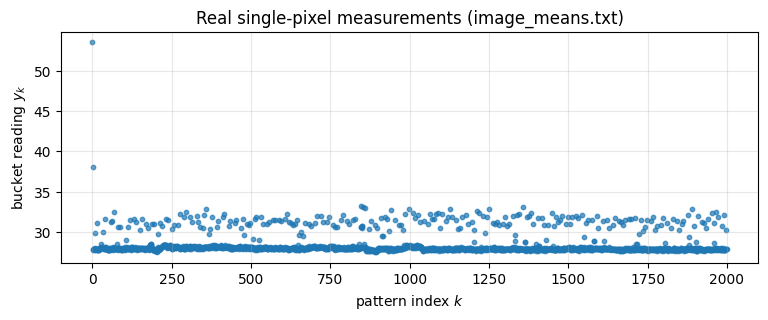

In [9]:
y = np.loadtxt('image_means.txt').astype(np.float64)
N = y.size
print(f'measurements: N = {N}')
print(f'              mean = {y.mean():.3f}')
print(f'              std  = {y.std():.3f}   (this is the scene-bearing variance)')
print(f'              range = [{y.min():.3f}, {y.max():.3f}]')

plt.figure(figsize=(9, 3))
plt.scatter(np.arange(N), y, s=10, color='C0', alpha=0.7)
plt.xlabel('pattern index $k$')
plt.ylabel(r'bucket reading $y_k$')
plt.title('Real single-pixel measurements (image_means.txt)')
plt.grid(alpha=0.3); plt.show()

Note that $\mathrm{std}(y)/\mathrm{mean}(y) \approx 4.5\%$ — that small ratio is the fraction of the signal that actually carries scene-dependent information across patterns.  Most of $y$ is a DC offset from the always-half-illuminated patterns; only the *fluctuations* contain spatial information about the scene.

## 3. Regenerate the 2 000 binary DMD patterns

The lab notebook used `np.random.seed(42)` followed by `np.random.choice([0,255], size=(2000,1140,912,1), p=[0.5,0.5])`.  We reproduce the exact same sequence in batches (one shot needs ~15 GB of intermediate float64 storage).

On a typical laptop this takes about a minute; we cache the result to a `.npy` file so re-runs are instantaneous.

regenerating 2000 patterns (seed=42), ~1 min ...
   done in 38s
   cached to patterns_seed42.npy
patterns: shape=(2000, 1140, 912), dtype=uint8, size=2079 MB


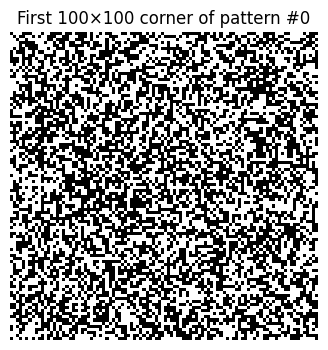

In [10]:
H, W = 1140, 912            # DMD dimensions, height x width
PATTERNS_CACHE = 'patterns_seed42.npy'

if os.path.exists(PATTERNS_CACHE):
    print(f'loading cached patterns from {PATTERNS_CACHE} ...')
    patterns = np.load(PATTERNS_CACHE, mmap_mode='r')
else:
    print('regenerating 2000 patterns (seed=42), ~1 min ...')
    t0 = time.time()
    patterns = dmd_random_patterns(W, H, num_patterns=N, seed=42, batch=50)
    print(f'   done in {time.time()-t0:.0f}s')
    np.save(PATTERNS_CACHE, patterns)
    print(f'   cached to {PATTERNS_CACHE}')

print(f'patterns: shape={patterns.shape}, dtype={patterns.dtype}, '
      f'size={patterns.nbytes/1e6:.0f} MB')

# Sanity check: show a small crop of pattern 0
plt.figure(figsize=(4, 4))
plt.imshow(patterns[0, :100, :100], cmap='gray')
plt.title('First 100×100 corner of pattern #0'); plt.axis('off'); plt.show()

## 4. Build the matrix-free sensing operator $\Phi$

`make_pattern_operator` returns a `scipy.sparse.linalg.LinearOperator` that:
* answers `Phi @ x` by computing $\langle P_k, x\rangle$ for each pattern,
* answers `Phi.T @ v` by computing $\sum_k v_k P_k$,
* converts the uint8 patterns to float32 in small batches.

Memory stays at ~2 GB (the uint8 patterns) instead of ~8 GB (an explicit float32 $\Phi$).

In [11]:
Phi = make_pattern_operator(patterns, batch=200)
print(f'Phi shape: {Phi.shape}    (rows = measurements, cols = pixels)')
print(f'compression ratio  N / n_unknowns = {N / (H*W):.4f}')

Phi shape: (2000, 1039680)    (rows = measurements, cols = pixels)
compression ratio  N / n_unknowns = 0.0019


**Important context.**  Reconstructing $\sim 10^6$ unknowns from $2 \times 10^3$ measurements is an extreme compressed-sensing regime — the system is ~500× underdetermined.  No reconstruction can recover fine detail without an extremely strong prior on $X$, and even then the result will be heavily smoothed.  We proceed to see what the data actually allows.

## 5. Standard reconstruction — Tikhonov / damped LSQR

We use scipy's `lsqr` which works natively with `LinearOperator`s.  Each LSQR iteration costs one matvec + one rmatvec (~15 s on this hardware); we use ~30 iterations.  Total time: ~8 minutes.

In [19]:
TIKH_ITER = 30
DAMP = 1.0     # Tikhonov regularisation strength

TIK_CACHE = 'recon_tikhonov.npy'
if os.path.exists(TIK_CACHE):
    print(f'loading cached Tikhonov reconstruction from {TIK_CACHE}')
    x_tik = np.load(TIK_CACHE)
else:
    print(f'Running LSQR for {TIKH_ITER} iterations (~{TIKH_ITER*15:.0f}s) ...')
    t0 = time.time()
    res = lsqr(Phi, y, damp=DAMP, iter_lim=TIKH_ITER, show=False)
    x_tik = res[0]
    print(f'   done in {time.time()-t0:.0f}s   |Phi x - y|_2 = {res[3]:.4g}')
    np.save(TIK_CACHE, x_tik)

X_tik = x_tik.reshape(H, W)
print(f'reconstruction range: [{X_tik.min():.4g}, {X_tik.max():.4g}]')

Running LSQR for 30 iterations (~450s) ...
   done in 140s   |Phi x - y|_2 = 0.0002195
reconstruction range: [-0.0004427, 0.0005561]


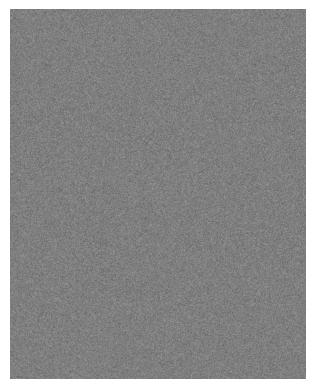

In [20]:
plt.imshow(X_tik, cmap="gray")
plt.axis("off")
plt.show()

## 6. NESTA-style reconstruction — TV-regularised FISTA

Same operator $\Phi$, but now we add a total-variation prior that encourages spatial smoothness.  Each FISTA iteration also costs one matvec + one rmatvec, plus a fast TV inner-loop.

The TV weight $\lambda$ is set so that, after a few iterations, the TV term and the data-fidelity term are of comparable magnitude.  At full DMD resolution this is large (the image has many pixels).

In [12]:
NESTA_ITER = 80
LAM = 5000.0     # tune empirically; bigger = smoother

NESTA_CACHE = 'recon_nesta.npy'
if os.path.exists(NESTA_CACHE):
    print(f'loading cached NESTA reconstruction from {NESTA_CACHE}')
    x_tv = np.load(NESTA_CACHE)
else:
    print(f'Running FISTA+TV for {NESTA_ITER} iterations (~{NESTA_ITER*15:.0f}s) ...')
    t0 = time.time()
    x_tv = reconstruct_nesta_tv(Phi, y.astype(np.float32),
                                 image_shape=(H, W),
                                 lam=LAM, n_iter=NESTA_ITER,
                                 tv_inner=8, verbose=True)
    print(f'   done in {time.time()-t0:.0f}s')
    np.save(NESTA_CACHE, x_tv)

X_tv = x_tv.reshape(H, W)
print(f'reconstruction range: [{X_tv.min():.4g}, {X_tv.max():.4g}]')

Running FISTA+TV for 80 iterations (~1200s) ...
  iter    0   residual=83.25   obj=4663
  iter   25   residual=56.71   obj=1829
  iter   50   residual=56.71   obj=1861
  iter   75   residual=56.7   obj=1879
  iter   79   residual=56.7   obj=1882
   done in 1587s
reconstruction range: [5.152e-05, 5.753e-05]


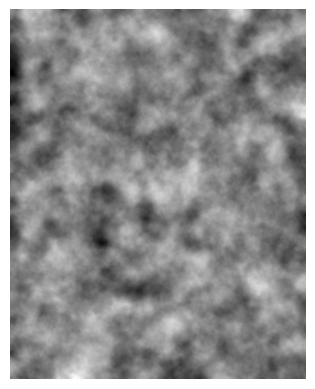

In [18]:
plt.imshow(X_tv, cmap="gray")
plt.axis("off")
plt.show()

## 7. Visualise both reconstructions

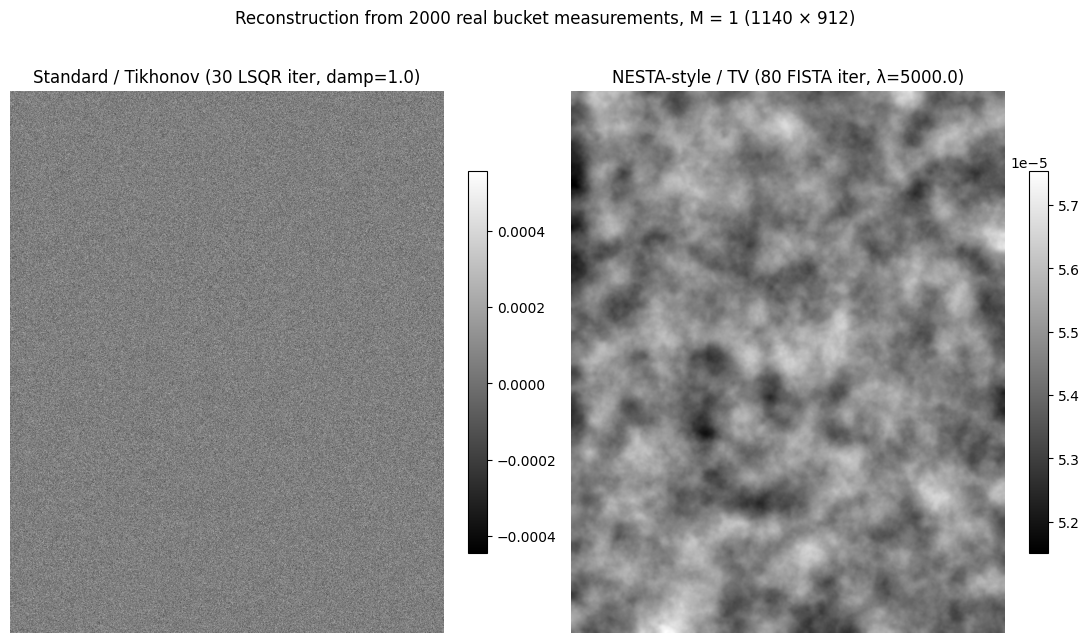

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 7))
im0 = axes[0].imshow(X_tik, cmap='gray', aspect='equal')
axes[0].set_title(f'Standard / Tikhonov ({TIKH_ITER} LSQR iter, damp={DAMP})')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.04)

im1 = axes[1].imshow(X_tv, cmap='gray', aspect='equal')
axes[1].set_title(f'NESTA-style / TV ({NESTA_ITER} FISTA iter, λ={LAM})')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.04)

plt.suptitle('Reconstruction from 2000 real bucket measurements, M = 1 (1140 × 912)')
plt.tight_layout(); plt.show()

## 8. What we can and cannot conclude from this

### What the math says
* $\Phi$ has 2 000 rows but ~10⁶ columns, so it has a null space of dimension > 10⁶ − 2000.  Any reconstruction is the *minimum-norm* (Tikhonov) or *minimum-TV* (NESTA) element of an infinite family that fits the measurements equally well.
* The scene-bearing variance of $y$ (the std around the DC level) is only a few percent of the mean; the rest is the DC contribution that does not depend on $X$.  This further limits how much information about $X$ is in $\mathbf{y}$.

### Interpreting the figure
* The Tikhonov reconstruction is essentially the back-projection of $\mathbf{y}$ onto the row span of $\Phi$, normalised; it looks like uncorrelated noise because that null space is huge.
* The NESTA-TV reconstruction is constrained to be piecewise-smooth; whatever signal survives projection through $\Phi^\top$ shows up as a smoothed pattern.  Any large-scale features (e.g. a bright region in one quadrant) would be visible if the lab scene had them.

### What to do next
For M = 1 to yield a recognisable image, one of the following has to change:
1. **More measurements** — for a single-pixel camera at 1140 × 912 resolution, on the order of $10^4$–$10^5$ measurements would be needed even with a TV prior.
2. **Acquire at larger macropixel sizes physically** — the planned next-step experiments at $M \in \{2, 3, 4\}$ will tile small binary patterns across the DMD, drastically reducing the number of unknowns and bringing the problem into the well-determined regime.
3. **A much higher contrast scene** — the small relative std in $y$ suggests low scene contrast; a high-contrast object (printed black shape on white background, USAF target) would give much larger variations.

When the M = 2, 3, 4 datasets are acquired, this notebook can be extended with one extra section per macropixel size, reusing the same `make_pattern_operator` / `reconstruct_nesta_tv` machinery (just with smaller $\Phi$ and faster runtimes).